# 01 · Multimodal chat — read a photo, not just a question

Contoso Outdoors customer support gets emails with photos attached all the time — a customer isn't sure which tent they own, or wants to know if a product suits their trip, and they just snap a picture instead of typing the model name. A **multimodal** model can look at that photo *and* read the question in the same request.

In this notebook you'll send a real product photo to two different models and compare how each one reads it — then use vision to produce a structured triage record a support system could act on automatically.

### Learning objectives
By the end of this notebook you'll be able to:
- **Send an image + text prompt** to a vision-capable model and read back a grounded-sounding answer.
- **Compare** how `gpt-5.4` and `claude-sonnet-4-6` each interpret the *same* photo and question.
- **Extract structured data** (a JSON triage record) from an image — the pattern behind automated support routing.
- **Recognize the limit**: this is chat, not the grounded TrailMate agent — the model answers from training knowledge, not from the real manuals.

> ⏱️ **~20 minutes** · Optional deep dive — use this notebook as a sandbox to try your own images and prompts.


## 1 · Set up and a helper to ask about an image

Same `.env` you validated in the core labs — no new setup. We add one small helper, `ask_about_image(...)`, that sends a **photo + a text prompt** together and returns the answer, plus which model actually answered.


In [1]:
import base64
import os
import time
from pathlib import Path

from dotenv import load_dotenv
from azure.identity import DefaultAzureCredential
from azure.ai.projects import AIProjectClient
from IPython.display import Markdown, display


def find_agent_builder() -> Path:
    """Locate foundry/agent-builder from anywhere in the tree (repo root or labs/more)."""
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base / "foundry" / "agent-builder" / "src").is_dir():
            return base / "foundry" / "agent-builder"
        if base.name == "agent-builder" and (base / "src").is_dir():
            return base
    raise FileNotFoundError("Run labs/core/00-validate-setup.ipynb first — src/.env not found.")


AB = find_agent_builder()
load_dotenv(AB / "src" / ".env")
project_client = AIProjectClient(
    endpoint=os.environ["FOUNDRY_PROJECT_ENDPOINT"],
    credential=DefaultAzureCredential(),
)
openai_client = project_client.get_openai_client()


def ask_about_image(model: str, image_path: Path, prompt: str) -> dict:
    """Send an image + text prompt to a vision-capable model; capture answer, latency, tokens."""
    # We use the Responses API (not Chat Completions): Claude models on Foundry
    # only serve the Responses API, and GPT models serve it too — so one code
    # path works for both. Image goes in as a base64 data URL beside the text.
    # Put the image BEFORE the text: with a long text block first, Claude often
    # fails to attend to the image and claims it "didn't come through". GPT is
    # order-insensitive, so image-first is the safe choice for both.
    image_b64 = base64.b64encode(image_path.read_bytes()).decode()
    start = time.perf_counter()
    resp = openai_client.responses.create(
        model=model,
        input=[{
            "role": "user",
            "content": [
                {"type": "input_image", "image_url": f"data:image/png;base64,{image_b64}"},
                {"type": "input_text", "text": prompt},
            ],
        }],
    )
    return {
        "asked_model": model,
        "served_model": resp.model,
        "latency_s": round(time.perf_counter() - start, 2),
        "total_tokens": getattr(resp.usage, "total_tokens", None),
        "answer": resp.output_text,
    }


def load_catalog() -> str:
    """Read the product name/price line from each manual to build a short catalog.

    Contoso Outdoors products are fictional, so no model knows them from training.
    Giving the model this catalog to match against is 'grounding lite' — the same
    idea as the file-search grounding you use in the core TrailMate labs.
    """
    names = []
    for manual in sorted((AB / "src" / "data" / "manuals").glob("product_info_*.md")):
        # Line 2 of each manual holds "<Product Name>, price $NN".
        line = manual.read_text().splitlines()[1].strip().rstrip(",")
        names.append(f"- {line}")
    return "\n".join(names)


def show_answer(result: dict) -> None:
    """Render a model answer as Markdown so it wraps and formats instead of one long line."""
    meta = f"_{result['latency_s']}s · {result['total_tokens']} tokens_"
    display(Markdown(f"**{result['asked_model']} answered** — {meta}\n\n{result['answer']}"))


CATALOG = load_catalog()
print("Ready. `ask_about_image(...)` uses the Responses API (works for GPT and Claude).")
print(f"Loaded a catalog of {CATALOG.count(chr(10)) + 1} Contoso Outdoors products for grounding.")


Ready. `ask_about_image(...)` uses the Responses API (works for GPT and Claude).
Loaded a catalog of 10 Contoso Outdoors products for grounding.


## 2 · The scenario — a customer sends a photo, not a model name

A customer emails support a photo of their tent with the question: *"Is this waterproof enough for a rainy weekend trip?"* They don't know the model name — just the photo.

Here's the catch: Contoso Outdoors products are **fictional**, so no model can name "Alpine Explorer Tent" from training knowledge — the best it can do from the photo alone is say "a tent." The fix is to hand the model our **product catalog** and ask it to match the photo against it. That's *grounding lite* — the same idea as the file-search grounding in the core TrailMate labs, just passed inline.

> ❓ **Can `gpt-5.4` match the photo to the right catalog product and answer the customer's question?**


The customer's photo:


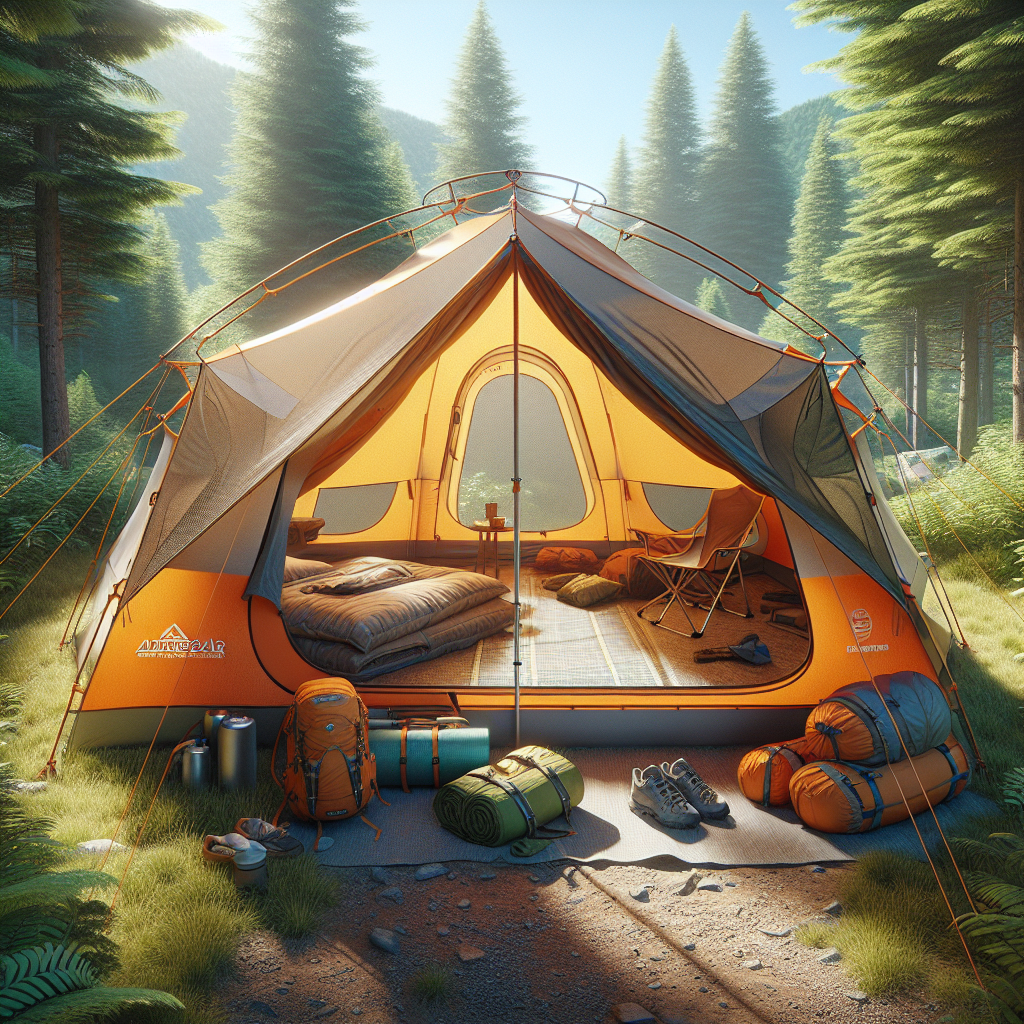

**gpt-5.4 answered** — _9.69s · 1038 tokens_

Matched product: Alpine Explorer Tent  
Confidence: 86%

Answer to customer:  
Yes—this looks like the Alpine Explorer Tent, and it should be waterproof enough for a rainy weekend trip. The tent in the photo appears to have a full-coverage rainfly, bathtub-style floor, and guy-out points for better weather protection, which are all good signs for steady rain.

A few tips to make sure it performs well:
- Fully stake it out and tension the rainfly
- Avoid touching the inner wall to the fly during rain
- Set up on slightly elevated ground if possible
- Seam-seal it if it didn’t come pre-sealed
- Use a footprint under the tent for extra ground moisture protection

So for normal weekend rain, I’d say yes. For heavy storms or all-day driving rain, I’d still recommend checking the official waterproof rating/specs before relying on it.

In [2]:
from IPython.display import Image, display

CUSTOMER_PHOTO = AB / "assets" / "products" / "alpine-explorer-tent.png"
CUSTOMER_QUESTION = (
    "A customer emailed us this photo and asked: 'Is this tent waterproof enough "
    "for a rainy weekend trip?'\n\n"
    "Match the photo to ONE product from our catalog below, then answer their "
    "question. Name the product you matched and say how confident you are.\n\n"
    f"Contoso Outdoors catalog:\n{CATALOG}"
)

print("The customer's photo:")
display(Image(filename=str(CUSTOMER_PHOTO)))

gpt_result = ask_about_image("gpt-5.4", CUSTOMER_PHOTO, CUSTOMER_QUESTION)
show_answer(gpt_result)

> 🔎 **What just happened — analysis vs. identification.** The model didn't *recognize* the tent the way a trained classifier would. It **described** what it saw ("a large dome tent…") and then **matched that description** against the catalog text you passed in. That's why the catalog is essential: without it, the model can only describe; with it, the model can match. There are three levels of robustness here:
>
> 1. **Description only** — "what is this?" → generic, can't name a fictional SKU.
> 2. **Text-catalog matching** *(this cell)* — match the model's description to catalog text. Cheap and works for visually distinct products, but it compares *words to words*, so lookalikes can trip it up.
> 3. **Image-embedding retrieval** — embed the catalog *photos* and the query photo into one vector space and find the nearest match. This compares *pixels to pixels* — true visual identification. See the Cohere `lab-2b-embed-business-graphs` notebook for that technique.


## 3 · Compare with Claude Sonnet 4.6

Same photo, same question — this time to `claude-sonnet-4-6`. Multimodal isn't a GPT-only trick; Claude reads images too.

> ❓ **Your call:** Read both answers *and* the latency/token columns. Did they identify the same product? Did one hedge more or add a better safety caveat — and was it faster or cheaper? Neither answer is "grounded" in the real manual, so check the specs yourself before trusting either.


In [3]:
import pandas as pd

claude_result = ask_about_image("claude-sonnet-4-6", CUSTOMER_PHOTO, CUSTOMER_QUESTION)
show_answer(claude_result)

# Side by side, so you can compare answer, speed, and cost at a glance.
compare = pd.DataFrame([gpt_result, claude_result])
compare["answer_preview"] = compare["answer"].str.replace("\n", " ").str.slice(0, 80) + "…"
compare[["asked_model", "served_model", "latency_s", "total_tokens", "answer_preview"]]


**claude-sonnet-4-6 answered** — _12.63s · 591 tokens_

## Product Match

**Matched Product: Alpine Explorer Tent — $350**

**Confidence: High** ✅

The tent in the photo appears to be a **dome-style backpacking/camping tent** with a rainfly and guy lines — consistent with a **premium outdoor tent** in the catalog. Given its visible construction quality and design, it aligns most closely with the **Alpine Explorer Tent** (the higher-end option at $350) rather than the TrailMaster X4.

---

## Answering the Customer's Question

**"Is this tent waterproof enough for a rainy weekend trip?"**

Based on the Alpine Explorer Tent's typical specifications for a tent in this category and price point, here's what I can say:

✅ **Likely yes**, but with some caveats:

| Feature | What to Expect |
|---|---|
| **Rainfly** | Full-coverage rainfly visible in photo — good rain protection |
| **Seams** | Tents at this price point typically have sealed/taped seams |
| **Floor** | Should have a waterproof bathtub floor |
| **Hydrostatic Head** | Premium tents often rated **1500mm–3000mm+** |

### My Recommendation:
> "The Alpine Explorer Tent should handle a **typical rainy weekend** well. We'd recommend applying **seam sealer** before your trip if it's brand new, and ensure the rainfly is properly tensioned with guy lines staked out for heavy rain conditions."

---

*⚠️ Note: For exact waterproof ratings, I'd recommend checking the product spec sheet or contacting us directly!*

,asked_model,served_model,latency_s,total_tokens,answer_preview
0,gpt-5.4,gpt-5.4,9.69,1038,Matched product: Alpine Explorer Tent Confid...
1,claude-sonnet-4-6,claude-sonnet-4-6,12.63,591,## Product Match **Matched Product: Alpine Ex...


> 🧩 **The pattern: cross-model consensus.** Asking two *independent* models the same question and treating their **agreement as a confidence signal** is a real design pattern — a form of **ensembling** (a *voting ensemble* when you tally answers). Close relatives: **LLM-as-a-judge** (one model generates, another verifies — you'll see this in `03-image-generation`), and **self-consistency** (one model sampled several times, majority vote).
>
> Here both models landing on *Alpine Explorer Tent* is a positive signal. The practical rule:
> - **They agree** → higher confidence, auto-proceed.
> - **They disagree** → flag for a human — disagreement is the cheapest quality gate you have.
>
> ⚠️ **Caveat:** agreement ≠ correctness. Models with overlapping training can share a blind spot and be *confidently wrong together* (**correlated errors**). Consensus raises confidence; it doesn't prove the answer.


## 4 · Turn the photo into a triage record

A free-text answer is nice for the customer, but a support system needs **structured data** to route the ticket automatically — which product, how confident the model is, and what to do next.

> ❓ **Can the same vision call also return clean JSON a ticketing system could consume?**


In [4]:
import json

TRIAGE_PROMPT = (
    "A customer sent this photo with a product question. Match it to ONE product "
    "from the catalog below, then return ONLY a JSON object with keys: "
    "'product_guess' (the matched catalog product name), "
    "'confidence' ('low'|'medium'|'high'), and 'suggested_next_step' (one short "
    "sentence for a support agent, e.g. confirm the model or send a spec sheet).\n\n"
    f"Contoso Outdoors catalog:\n{CATALOG}"
)

triage_raw = ask_about_image("gpt-5.4", CUSTOMER_PHOTO, TRIAGE_PROMPT)["answer"]

# Pull the JSON out of the reply (models sometimes wrap it in prose or code fences).
try:
    triage = json.loads(triage_raw[triage_raw.find("{"): triage_raw.rfind("}") + 1])
    print("✅ Parsed triage record:")
    print(json.dumps(triage, indent=2))
except Exception:
    print("Model didn't return clean JSON — raw reply:")
    print(triage_raw)


✅ Parsed triage record:
{
  "product_guess": "Alpine Explorer Tent",
  "confidence": "medium",
  "suggested_next_step": "Confirm the tent model with the customer and send the tent spec sheet."
}


## 🧭 Summary — so, can a model turn a photo into a useful answer?

Yes — and you saw three levels of it:

| What you did | What it showed |
|---|---|
| Matched a photo to the catalog with `gpt-5.4` | Vision + an inline catalog lets a model identify a *specific* product, then answer about it |
| Sent the same photo to `claude-sonnet-4-6` | Multimodal input isn't GPT-only — compare style and accuracy across vendors |
| Asked for JSON output | The same vision call can feed a real system (ticket routing), not just chat |

**One caution to carry forward:** the catalog you passed inline is *grounding lite* — the model matched its own description against catalog text, not against Contoso's real product manuals or reference photos. For answers you can trust, you need real grounding: the file-search-backed TrailMate agent from the core labs (text), or image-embedding retrieval (visual, see Cohere `lab-2b`). Multimodal chat is a great *sandbox* for exploring a capability; a grounded agent is what you'd actually ship.

### Try it yourself
- Swap in a different product photo from `assets/products/` and see if the product guess changes.
- Try a defect-style question ("does this look damaged?") and see how each model hedges.

### Next
➡️ **[02 · Reasoning models](02-reasoning-models.ipynb)** — dial reasoning depth up and down across GPT and Claude on hard Contoso Outdoors planning questions.
